# Exercise 4B. Classification, shallow learning, model evaluation and prediction

The aim of exercise 4 is to learn how to:
* train shallow learning models
* use the trained model to predict a whole image
* evaluate the model's accuracy
* see what features mostly contribute to the results

The task is land-use classification, based on 2 datasets: Sentinel-2 11-days mosaic and Google AlphaEarth data.

This exercise is split into 2 notebooks:
* `04A_shallow_classification_model_training.ipynb` for model training
* This notebook for model evaluation and prediction.

**04A notebook must be run twice (with Sentinel-2 and AlphaEarth data) before this one**

## Results
For each model (2 datasets x 2 models)
* Model accuracy estimation
* Class confusion matrix
* Predicted classification as GeoTIFFs
* Insight which features are important for the model

Models:
* Sentinel-2 + Random forest
* Sentinel-2 + Histogram-based Gradient Boosting Classification Tree
* AlphaEarth data + Random forest
* AlphaEarth data + Histogram-based Gradient Boosting Classification Tree

In [1]:
import os, time
from joblib import dump, load
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import pandas as pd
import rasterio
from rasterio.plot import show
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, jaccard_score
from sklearn.model_selection import GridSearchCV
%matplotlib inline

In [2]:
# Set folders and file paths
user = os.environ.get('USER')
base_folder = os.path.join('/scratch/project_2019932/students', user, 'GeoML')
dataFolder = os.path.join(base_folder,'data', 'raster', 'pixel-wise')
results_folder = os.path.join(base_folder, "classification_results")
classification_report_csv = os.path.join(results_folder, "classification_report_results.csv")
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

exerciseFolder= os.path.join(base_folder,'04_shallow_classification')
os.chdir(exerciseFolder)

# Source data local paths
multiclass_classification_file = os.path.join(dataFolder, 'labels.tif')

datasets = ["sentinel2", "alphaearth"]
models = ["random_forest", "hist_gradient_boosting"]

# Saved input files from exercise 2.
data_files = {
    datasets[0]: os.path.join(dataFolder, 'data_sentinel2.tif'),
    datasets[1]: os.path.join(dataFolder, 'data_alphaearth.tif')
}

# Saved test data from 4A
test_data_files = {
    datasets[0]: datasets[0] + "_test_data.npz",
    datasets[1]: datasets[1] + "_test_data.npz"
}

# The saved models from 4A
model_files = {
    (datasets[0],models[0]): "model_" + datasets[0] + "_" + models[0] + ".sav",
    (datasets[0],models[1]): "model_" + datasets[0] + "_" + models[1] + ".sav",
    (datasets[1],models[0]): "model_" + datasets[1] + "_" + models[0] + ".sav",
    (datasets[1],models[1]): "model_" + datasets[1] + "_" + models[1] + ".sav"
}

# Paths for GeoTIFFs created below
# Most likely class
predicted_classification = {
    (datasets[0],models[0]): os.path.join(results_folder, ('classification_' + datasets[0] + '_' + models[0] +  '.tif')),
    (datasets[0],models[1]): os.path.join(results_folder, ('classification_' + datasets[0] + '_' + models[1] +  '.tif')),
    (datasets[1],models[0]): os.path.join(results_folder, ('classification_' + datasets[1] + '_' + models[0] +  '.tif')),
    (datasets[1],models[1]): os.path.join(results_folder, ('classification_' + datasets[1] + '_' + models[1] +  '.tif'))
}

# Probabilities for all classes
probabilities_all_classes = {
    (datasets[0],models[0]): os.path.join(results_folder, ('class_probabilities_' + datasets[0] + '_' + models[0] +  '_all_classes.tif')),
    (datasets[0],models[1]): os.path.join(results_folder, ('class_probabilities_' + datasets[0] + '_' + models[1] +  '_all_classes.tif')),
    (datasets[1],models[0]): os.path.join(results_folder, ('class_probabilities_' + datasets[1] + '_' + models[0] +  '_all_classes.tif')),
    (datasets[1],models[1]): os.path.join(results_folder, ('class_probabilities_' + datasets[1] + '_' + models[1] +  '_all_classes.tif'))
}

In [3]:
#Give classes and bands names for plotting
class_names = ["other", "forest", "fields", "water"]
number_of_classes = len(class_names)

band_names = {
    datasets[0]: ["b02", "b03", "b04", "b05", "b06", "b07", "b08", "b01", "b11", "b12"],
    datasets[1]: [str(i) for i in range(1, 65)]
}

## Estimate models with test data

Load the models from the saved files. Here and below, each step is done for all 4 models.

In [4]:
trained_models = {}

for key, filepath in model_files.items():
    trained_models[key] = load(filepath)

trained_models

{('sentinel2',
  'random_forest'): RandomForestClassifier(max_depth=75, n_estimators=200, n_jobs=1, random_state=0),
 ('sentinel2', 'hist_gradient_boosting'): HistGradientBoostingClassifier(),
 ('alphaearth',
  'random_forest'): RandomForestClassifier(max_depth=75, n_estimators=200, n_jobs=1, random_state=0),
 ('alphaearth', 'hist_gradient_boosting'): HistGradientBoostingClassifier()}

Load the test data from the saved files

In [5]:
test_data = {}

for key, filepath in test_data_files.items():
    data = np.load(filepath)
    test_data[(key,"x")] = data["X_test"]
    test_data[(key,"y")] = data["y_test"]

#test_data

Calculate predictions for test data.

In [6]:
test_predictions = {}

for key, path in model_files.items():
    dataset, model = key
    clf = trained_models[(dataset,model)]
    test_predictions[key] = clf.predict(test_data[(dataset,"x")])

### Classification reports

In [7]:
for key, path in model_files.items():
    dataset, model = key
    print(model, dataset)
    print('Classification report: \n', classification_report(test_data[(dataset,"y")], test_predictions[key], target_names=class_names))

random_forest sentinel2
Classification report: 
               precision    recall  f1-score   support

       other       0.32      0.52      0.40     12602
      forest       0.95      0.86      0.91     78502
      fields       0.84      0.82      0.83     40630
       water       0.81      0.92      0.86      6046

    accuracy                           0.82    137780
   macro avg       0.73      0.78      0.75    137780
weighted avg       0.86      0.82      0.84    137780

hist_gradient_boosting sentinel2
Classification report: 
               precision    recall  f1-score   support

       other       0.32      0.50      0.39     12602
      forest       0.96      0.86      0.91     78502
      fields       0.83      0.82      0.83     40630
       water       0.79      0.90      0.84      6046

    accuracy                           0.82    137780
   macro avg       0.72      0.77      0.74    137780
weighted avg       0.85      0.82      0.83    137780

random_forest alphaeart

Save the results for later comparison.

In [8]:
classification_report_results = {}

# Get the same classification report as JSON
for key, path in model_files.items():
    dataset, model = key
    classification_report_results[key] = classification_report(test_data[(dataset,"y")], test_predictions[key], output_dict=True)

# Convert to Pandas dataframe
df = pd.json_normalize(list(classification_report_results.values()))
df.insert(0, "dataset", [k[0] for k in classification_report_results.keys()])
df.insert(1, "model", [k[1] for k in classification_report_results.keys()])

### Confusion matrices

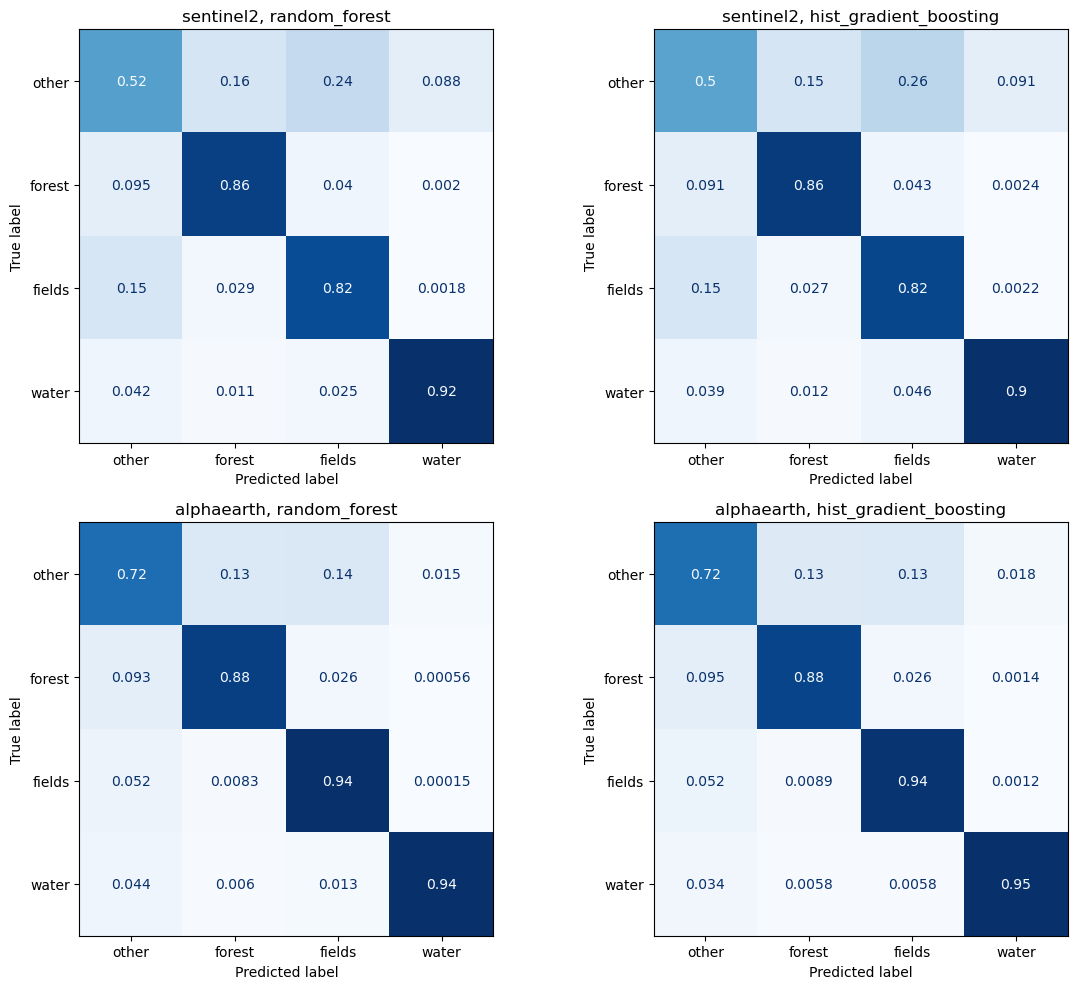

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (key, path) in zip(axes.flat, model_files.items()):
    dataset, model = key

    disp = ConfusionMatrixDisplay.from_predictions(
        test_data[(dataset, "y")],
        test_predictions[key],
        normalize='true',
        cmap=plt.cm.Blues,
        display_labels=class_names,
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"{dataset}, {model}")

plt.tight_layout()
plt.show()

### Jaccard score

In [10]:
df['jaccard'] = np.nan

for key, path in model_files.items():
    dataset, model = key
    jaccard_score_value = round(jaccard_score(test_data[(dataset,"y")], test_predictions[key], average='macro'), 3)
    print(jaccard_score_value, model, dataset)
    # Save the values to the dataframe
    mask = (df['dataset'] == dataset) & (df['model'] == model)
    df.loc[mask, 'jaccard'] = jaccard_score_value

0.636 random_forest sentinel2
0.627 hist_gradient_boosting sentinel2
0.756 random_forest alphaearth
0.755 hist_gradient_boosting alphaearth


### Save model metrics

In [11]:
# Have a look on the dataframe
df.head()

,dataset,model,accuracy,0.precision,0.recall,0.f1-score,0.support,1.precision,1.recall,1.f1-score,...,3.support,macro avg.precision,macro avg.recall,macro avg.f1-score,macro avg.support,weighted avg.precision,weighted avg.recall,weighted avg.f1-score,weighted avg.support,jaccard
0,sentinel2,random_forest,0.821411,0.322271,0.520156,0.397972,12602.0,0.954817,0.862488,0.906307,...,6046.0,0.731249,0.781240,0.748852,137780.0,0.857036,0.821411,0.835553,137780.0,0.636
1,sentinel2,hist_gradient_boosting,0.819988,0.318381,0.496191,0.387879,12602.0,0.956137,0.863570,0.907499,...,6046.0,0.724291,0.771566,0.741603,137780.0,0.853302,0.819988,0.833371,137780.0,0.627
2,alphaearth,random_forest,0.885666,0.483026,0.715839,0.576827,12602.0,0.971583,0.881086,0.924124,...,6046.0,0.830816,0.868541,0.843378,137780.0,0.907822,0.885666,0.893335,137780.0,0.756
3,alphaearth,hist_gradient_boosting,0.884657,0.482817,0.724647,0.579515,12602.0,0.972065,0.877659,0.922453,...,6046.0,0.825733,0.873488,0.842886,137780.0,0.907636,0.884657,0.892497,137780.0,0.755


In [12]:
# Save the dataframe
df.to_csv(classification_report_csv, index=False)

## Predict for data image area
### Predict most likely class

In [13]:
def predictImage(dataset, model):
    start_time = time.time()    

    # Read the pixel values from .tif file as dataframe
    with rasterio.open(data_files[dataset]) as image_dataset:
        image_data = image_dataset.read()
        no_bands_in_image = image_data.shape[0]
        image_data2 = np.transpose(image_data, (1, 2, 0))
        pixels = image_data2.reshape(-1, no_bands_in_image)
    
        # predict the class for each pixel
        trained_model = trained_models[(dataset, model)]
        prediction = trained_model.predict(pixels)
    
        # Reshape back to 2D
        prediction2D = np.reshape(prediction, (image_data.shape[1], image_data.shape[2]))
    
        # Save the results as .tif file.
        # Copy metadata from the labels image
        profile = image_dataset.meta.copy()
        profile.update(dtype=rasterio.uint16, count=1, nodata=2000)
        # Writing the image on the disk
        prediction_file = predicted_classification[(dataset, model)]
        with rasterio.open(prediction_file, 'w', **profile) as dst:
            dst.write(prediction2D, 1)
        print('Predicting took: ', dataset, model, round((time.time() - start_time), 1), ' seconds')

In [14]:
for key, path in model_files.items():
    dataset, model = key
    predictImage(dataset,model)

Predicting took:  sentinel2 random_forest 25.6  seconds
Predicting took:  sentinel2 hist_gradient_boosting 13.4  seconds
Predicting took:  alphaearth random_forest 27.0  seconds
Predicting took:  alphaearth hist_gradient_boosting 14.9  seconds


#### Plot predicted classification as map

In [15]:
# For better plotting of Sentinel image, normalize the values
# Help function to normalize band values and enhance contrast. Just like what QGIS does automatically
def normalize(rgb):
    min_percent = 2   # Low percentile
    max_percent = 98  # High percentile
    lo, hi = np.percentile(rgb, (min_percent, max_percent), axis=(0,1), keepdims=True)
    new_min, new_max = 1, 255
    rgb_norm = (rgb - lo) / (hi - lo) * (new_max - new_min) + new_min
    rgb_norm = rgb_norm.astype(np.uint8)    
    return rgb_norm.astype(np.uint8)

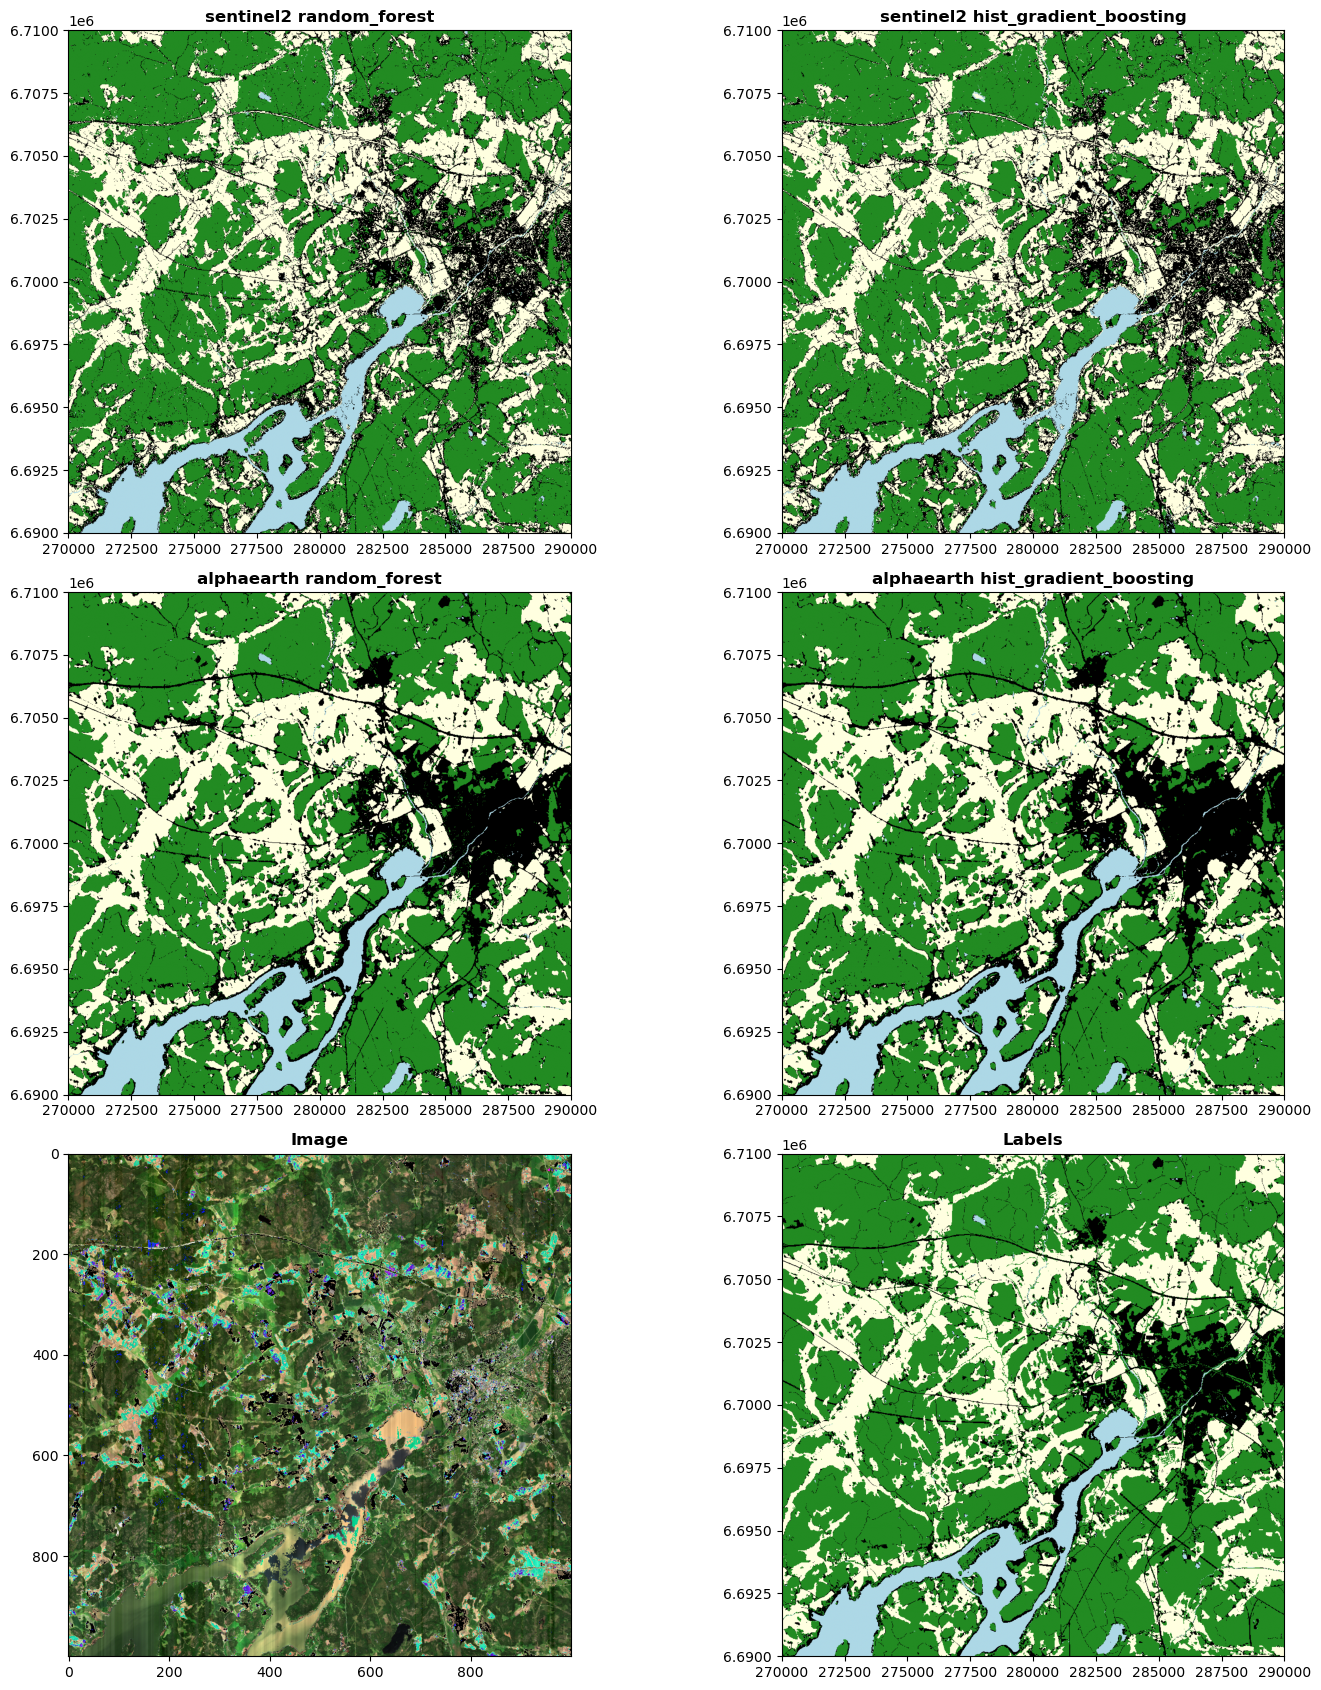

In [16]:
# Create a subplot for 6 images: 4 classification, 1 data image and 1 training labels. 
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(15,17))
cmap = ListedColormap(["black", "forestgreen", "lightyellow", "lightblue"])
for ax, (key, path) in zip(axes.flat, model_files.items()):
    dataset, model = key
    title = f"{dataset} {model}"

    with rasterio.open(predicted_classification[(dataset, model)]) as src:
        show(src, ax=ax, cmap=cmap, title=title)

# Plot the sentinel image 
with rasterio.open(data_files["sentinel2"]) as image_data:
    rgb = image_data.read([3, 2, 1])
    rgb_norm = normalize(rgb)
    show(rgb_norm, ax=axes[2,0], title='Image') 

# Labels 
with rasterio.open(multiclass_classification_file) as labels:
    show(labels, ax=axes[2,1], cmap=cmap,  title='Labels') 

plt.tight_layout()
plt.show()

### Predict class level probabilities

The above predicted the most likely class. Some Classifiers in `scikit-learn` have option also to get probabilities for all classes, inc random forest and histogram-based gradient boosting classification tree.

Define function to get for each pixel probabilities for each class.

In [17]:
def predictProbabilities(dataset, model):
    start_time = time.time()    

        # Read the pixel values from .tif file as dataframe
    with rasterio.open(data_files[dataset]) as image_dataset:
        image_data = image_dataset.read()
        no_bands_in_image = image_data.shape[0]
        image_data2 = np.transpose(image_data, (1, 2, 0))
        pixels = image_data2.reshape(-1, no_bands_in_image)
    
        # predict the class for each pixel
        trained_model = trained_models[(dataset, model)]
        prediction = trained_model.predict_proba(pixels)
    
        # Reshape back to 2D
        prediction2D = np.reshape(prediction, (image_data.shape[1], image_data.shape[2], number_of_classes))
        prediction2D = np.transpose(prediction2D, (2, 0, 1))
        
        # Save the results as .tif file.
        # Copy metadata from the labels image
        profile = image_dataset.meta.copy()
        profile.update(count=number_of_classes, dtype='float32')
        # Writing the image on the disk
        prediction_file = probabilities_all_classes[(dataset, model)]
        with rasterio.open(prediction_file, 'w', **profile) as dst:
            dst.write(prediction2D)
        print('Predicting took: ', dataset, model, round((time.time() - start_time), 1), ' seconds')

In [18]:
for key, path in model_files.items():
    dataset, model = key
    predictProbabilities(dataset,model)

Predicting took:  sentinel2 random_forest 24.6  seconds
Predicting took:  sentinel2 hist_gradient_boosting 13.6  seconds
Predicting took:  alphaearth random_forest 27.6  seconds
Predicting took:  alphaearth hist_gradient_boosting 15.6  seconds


#### Plot class-wise probabilites as map

Plot the probabilieis for all classes, most likely class and ground truth.

The cell below plots probabilities only for one dataset/model, compare the probabilities for different classes.

Change to other models/datasets. Compare for example Sentinel-2 and AlphaEarth probabilities.

/scratch/project_2019932/students/ekkylli/GeoML/classification_results/classification_sentinel2_hist_gradient_boosting_all_classes.tif


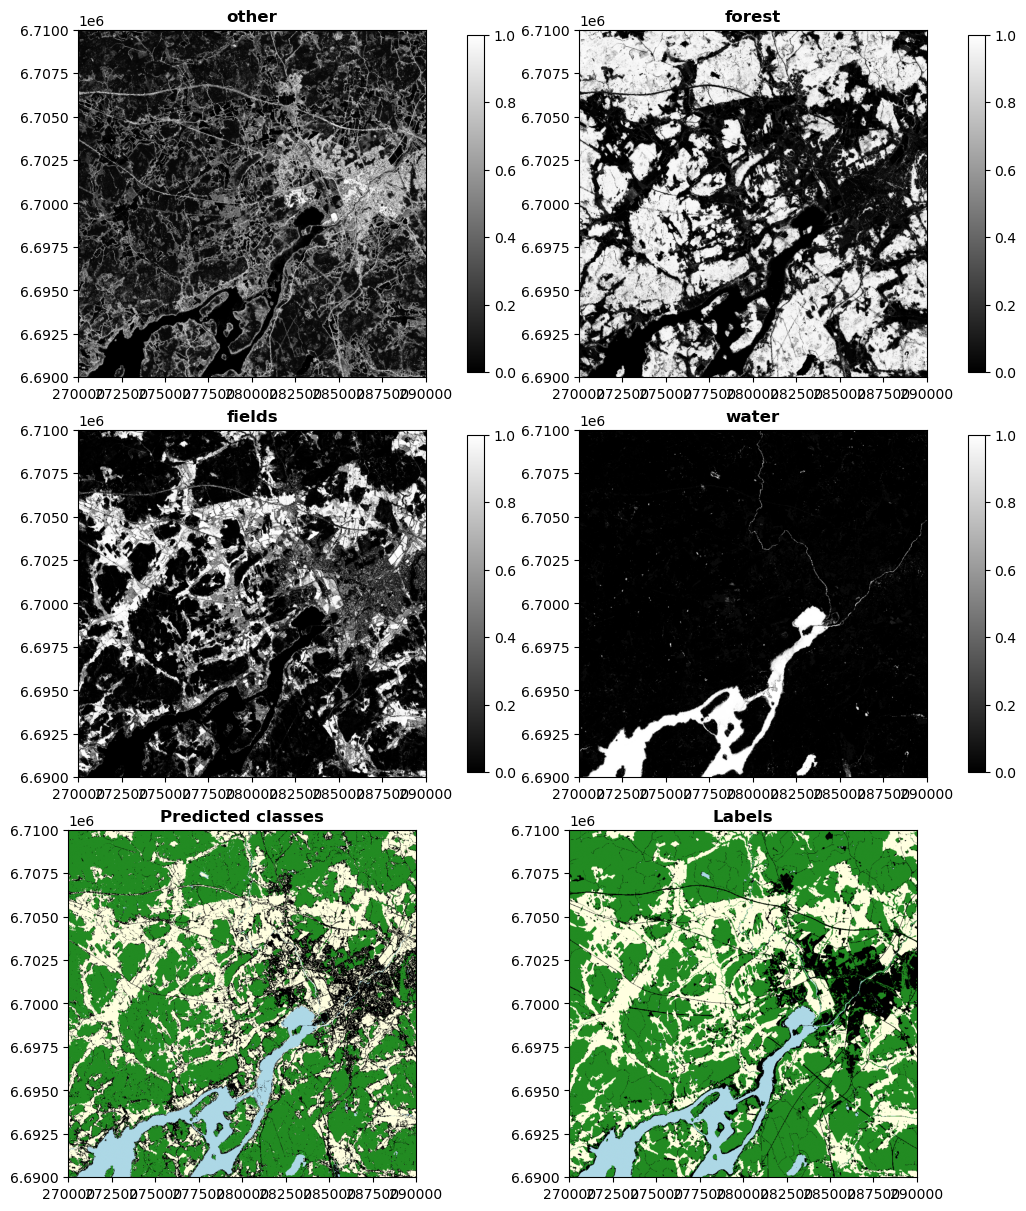

In [19]:
dataset = "sentinel2"
#dataset = "alphaearth"
#model_name = "random_forest" 
model_name = "hist_gradient_boosting"
probabilities_file = probabilities_all_classes[(dataset, model_name)]
print(probabilities_file)

fig, axes = plt.subplots(3, 2, figsize=(10, 12), constrained_layout=True)

with rasterio.open(probabilities_file) as src:
    data = src.read()
    transform = src.transform  # reuse this so top panels match bottom panels' coordinate space

    for i, ax in enumerate(axes.flat[:4]):
        im = show(data[i], ax=ax, cmap="gray", title=class_names[i], transform=transform)
        mappable = ax.images[0]  # grab the actual image artist for the colorbar
        ax.set_aspect("equal")
        fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)

with rasterio.open(predicted_classification[(dataset, model_name)]) as src:
    show(src, ax=axes[2, 0], cmap=cmap, title='Predicted classes')
    axes[2, 0].set_aspect("equal")

with rasterio.open(multiclass_classification_file) as labels:
    show(labels, ax=axes[2, 1], cmap=cmap, title='Labels')
    axes[2, 1].set_aspect("equal")

plt.show()

## What features are important?

### Feature importances

Random forest classifier provides also feature importances. Histogram-based Gradient Boosting Classification Tree does not have that option.

In [20]:
for key, model in trained_models.items():
    dataset, model_name = key
    if model_name == "random_forest":
        print(key)    
        print('Feature importances:')
        importances = list(zip(band_names[dataset], model.feature_importances_))
        # Sort descending by importance value
        importances_sorted = sorted(importances, key=lambda x: x[1], reverse=True)
        
        for importance in importances_sorted[:10]:
            print(importance)

('sentinel2', 'random_forest')
Feature importances:
('b12', np.float64(0.1607635942822605))
('b11', np.float64(0.12780122744759784))
('b08', np.float64(0.11135768867962476))
('b01', np.float64(0.10376088880032845))
('b03', np.float64(0.1010233218774236))
('b07', np.float64(0.09395916504843581))
('b02', np.float64(0.07901106734162368))
('b05', np.float64(0.07696922262392149))
('b04', np.float64(0.0729566436853893))
('b06', np.float64(0.07239718021339463))
('alphaearth', 'random_forest')
Feature importances:
('49', np.float64(0.05876976497822131))
('58', np.float64(0.04821447510427564))
('46', np.float64(0.04428173698154786))
('56', np.float64(0.04149201895328365))
('57', np.float64(0.03465912258392215))
('25', np.float64(0.03402678145607556))
('15', np.float64(0.03257019929154921))
('62', np.float64(0.031692395481132805))
('26', np.float64(0.03156692636815459))
('64', np.float64(0.030184991269263585))


### SHAP

We can also use SHAP (SHapley Additive exPlanations) to gain some insight of our model and our predictions. SHAP estimates how an individual feature has influenced predictions made by the model. For tree-based models such as RF, SHAP provides an especially efficient way to find each features' contribution by tracing back the decision path made by the model. This way it is able to compute all of the SHAP values exactly. 

In [21]:
# Get data for SHAP - extract a number of pixels from the data
# The number of pixels is very low here to keep the running time suitable for the course
# Otherwise take at least 100 points.
shap_data = {}

for dataset in datasets:
    X_full = test_data[(dataset, "x")]
    rng = np.random.default_rng(seed=42)
    idx = rng.choice(len(X_full), size=30, replace=False) # Increase the size here to get more datapoints.
    shap_data[dataset] = X_full[idx]

In [22]:
# Calculate SHAP values
shap_values = {}

for key, path in model_files.items():
    dataset, model = key

    clf = trained_models[(dataset, model)]
    explainer = shap.TreeExplainer(clf)
    shap_values[key] = explainer.shap_values(shap_data[dataset])

The SHAP summary plot shows the average impact of each input feature on the model's predictions. The results show that bands 'b12', 'b8a', and 'b03' have affected the outcome on average the most with the Sentinel 2 data. When using the AlphaEarth embeddings, we see that 'b12', 'b11', and 'b07' are the most important. 

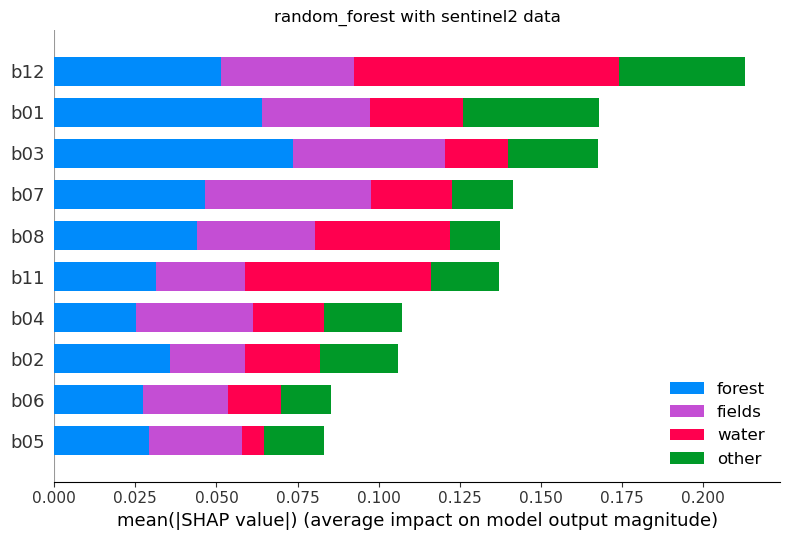

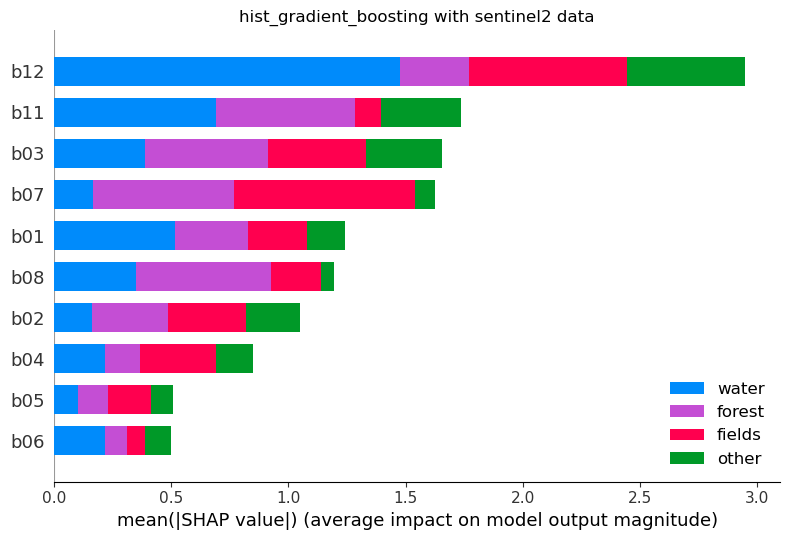

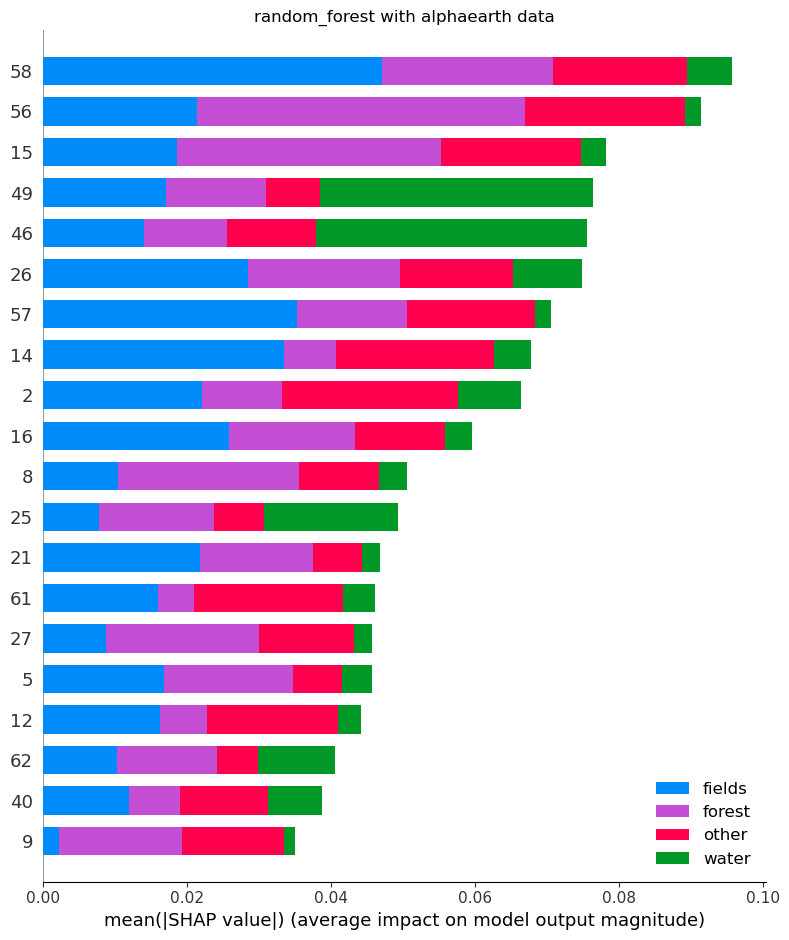

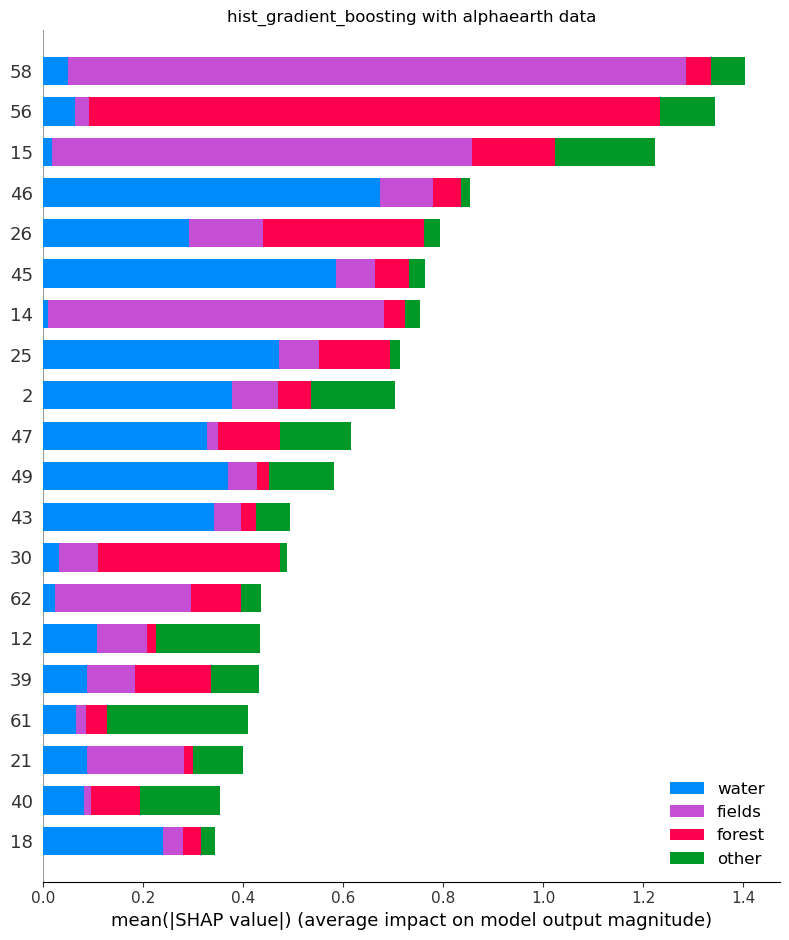

In [23]:
for key, path in model_files.items():
    dataset, model = key

    shap.summary_plot(
        shap_values[key], shap_data[dataset],
        plot_type="bar",
        feature_names=band_names[dataset],
        class_names=class_names,
        show=False
    )
    
    title = f"{model} with {dataset} data"   
    plt.title(title)
    plt.tight_layout()
    plt.show()

We can also visualize the feature importances using the SHAP violin plot for each class. The violin plot shows how each feature has affeacted each pixel's prediction - either pushing it towards or away from the average prediction for this class. From the color, we can in addition see the value of that particular sample (e.g. red = high, blue = low). 

For example, we see that for the sentinel2 data and the histogram gradient boosting model, the model's predictions for the forest class are mostly influenced by the bands b11, b08 and b07. The red color for the b08 band shows that a high value of this band pushes the prediction towards the class. The blue color for the b11 band shows that a low value of this band pushes the prediction away from the forest class. 

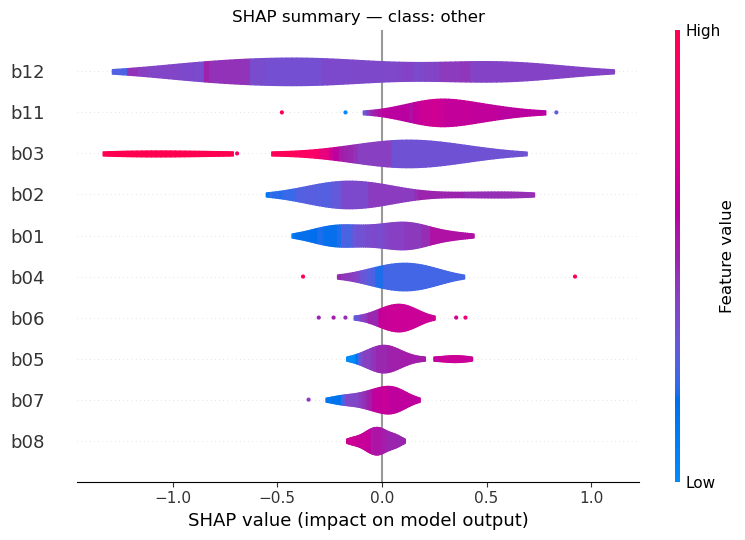

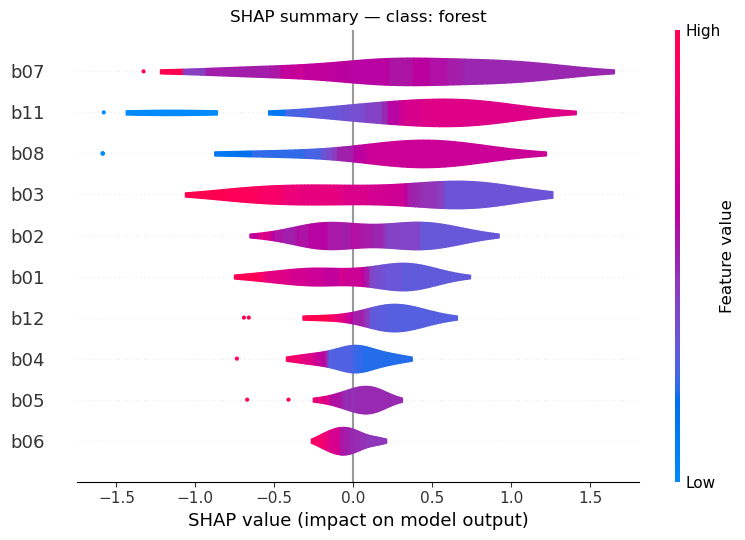

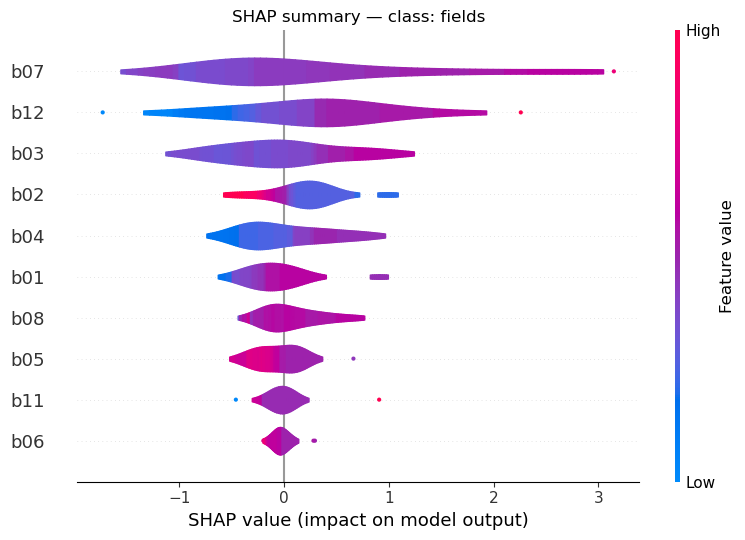

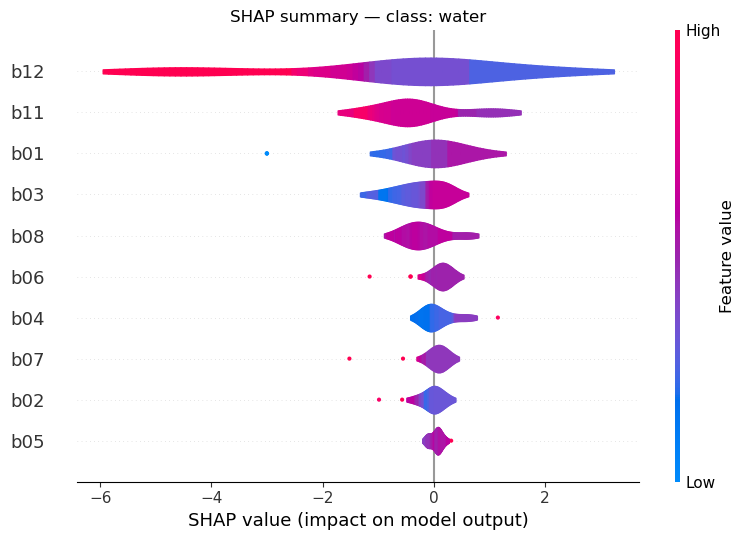

In [24]:
# The last plot is only for one model, change to other models, if you want
dataset = "sentinel2" 
#dataset = "alphaearth"
#model_name = "random_forest" 
model_name = "hist_gradient_boosting"

for i, class_name in enumerate(class_names):
    shap_class_i = shap_values[(dataset,model_name)][:, :, i]   

    shap.summary_plot(
        shap_class_i,
        shap_data[dataset],
        feature_names=band_names[dataset],
        plot_type="violin",
        show=False
    )
    plt.title(f"SHAP summary — class: {class_name}")
    plt.tight_layout()
    plt.show()